In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("Environment ready. Libraries imported successfully.")

Environment ready. Libraries imported successfully.


In [2]:
# Set seed for reproducibility
np.random.seed(42)
samples_per_class = 2000
data = []

for label in [0, 1, 2, 3]:
    for _ in range(samples_per_class):
        if label == 0:  # SAFE
            vibration = np.random.uniform(0.05, 1.2)
            acceleration = np.random.uniform(0.01, 0.3)
            fire = np.random.uniform(10.0, 50.0)
            damage = 0
        elif label == 1:  # WATCH
            vibration = np.random.normal(3.5, 1.0)
            acceleration = np.random.normal(1.5, 0.5)
            fire = np.random.uniform(15.0, 70.0)
            damage = 0
        elif label == 2:  # DANGER
            vibration = np.random.normal(8.0, 2.0)
            acceleration = np.random.normal(5.0, 1.2)
            fire = (
                np.random.uniform(200.0, 600.0)
                if np.random.rand() < 0.3
                else np.random.uniform(20.0, 90.0)
            )
            damage = 1 if np.random.rand() < 0.15 else 0
        elif label == 3:  # EVACUATE
            vibration = np.random.normal(13.0, 1.8)
            acceleration = np.random.normal(9.5, 2.0)
            fire = (
                np.random.uniform(500.0, 950.0)
                if np.random.rand() < 0.8
                else np.random.uniform(50.0, 150.0)
            )
            damage = 1 if np.random.rand() < 0.85 else 0

        # Clip values to represent physical limits of Arduino hardware
        vibration = max(0.02, min(15.0, vibration))
        acceleration = max(0.0, min(19.6, acceleration))  # Cap at ~2g
        fire = max(0.0, min(1023.0, fire))  # 10-bit ADC standard range

        data.append([vibration, acceleration, fire, damage, label])

# Create and shuffle DataFrame
columns = [
    "vibration_hz",
    "acceleration_m2s",
    "fire_sensor",
    "structural_damage",
    "risk_label",
]
df = pd.DataFrame(data, columns=columns)
df = df.sample(frac=1).reset_index(drop=True)

# Save to CSV
df.to_csv("sensor_data_v2.csv", index=False)
print("Dataset 'sensor_data_v2.csv' successfully generated and saved!")

Dataset 'sensor_data_v2.csv' successfully generated and saved!


In [3]:
# Load dataset
df_verify = pd.read_csv("sensor_data_v2.csv")

# Define features and label targets
FEATURES = ["vibration_hz", "acceleration_m2s", "fire_sensor", "structural_damage"]
X = df_verify[FEATURES]
y = df_verify["risk_label"]

# Split data (80% train, 20% test) matching stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and fit the scaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and normalized using MinMaxScaler.")

Data successfully split and normalized using MinMaxScaler.


In [4]:
# Initialize Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Random Forest model training complete!")

Random Forest model training complete!


In [5]:
# Export the trained model and fit scaler files to the working folder
joblib.dump(model, "seismic_rf_model.pkl")
joblib.dump(scaler, "seismic_scaler.pkl")

print("Files 'seismic_rf_model.pkl' and 'seismic_scaler.pkl' exported successfully!")

Files 'seismic_rf_model.pkl' and 'seismic_scaler.pkl' exported successfully!


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        SAFE       1.00      1.00      1.00       400
       WATCH       1.00      0.99      1.00       400
      DANGER       0.99      0.98      0.99       400
    EVACUATE       0.99      1.00      0.99       400

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



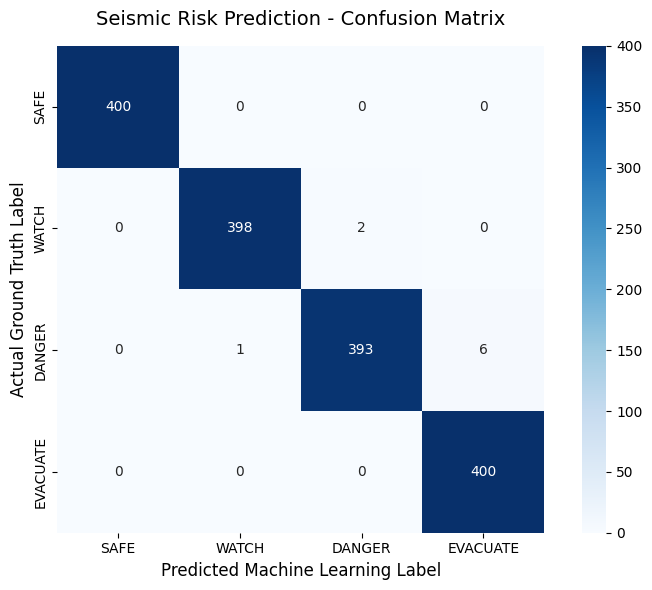

In [6]:
target_names = ["SAFE", "WATCH", "DANGER", "EVACUATE"]

# 1. Print Text Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=target_names))

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=True,
    square=True,
)

plt.title("Seismic Risk Prediction - Confusion Matrix", fontsize=14, pad=15)
plt.ylabel("Actual Ground Truth Label", fontsize=12)
plt.xlabel("Predicted Machine Learning Label", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Load components to verify integrity for the live prototype
deployed_model = joblib.load("seismic_rf_model.pkl")
deployed_scaler = joblib.load("seismic_scaler.pkl")

def live_monitor_simulation(seconds=10):
    status_labels = {0: "SAFE", 1: "WATCH", 2: "DANGER", 3: "EVACUATE"}
    print("--- STARTING REAL-TIME STRUCTURAL MONITORING ---")

    for i in range(seconds):
        if i < 5:
            # Simulate regular structural metrics (Safe state)
            vibration = np.random.uniform(0.1, 0.4)
            accel = np.random.uniform(0.01, 0.08)
            fire = np.random.uniform(15.0, 25.0)
            damage = 0
        else:
            # Simulate a severe seismic event kicking in
            vibration = 11.8
            accel = 7.9
            fire = 480.0
            damage = 1

        # Format input raw data into a DataFrame matching feature names
        current_reading = pd.DataFrame(
            [[vibration, accel, fire, damage]], columns=FEATURES
        )

        # Scale the inputs using the exact training boundaries
        current_reading_scaled = deployed_scaler.transform(current_reading)

        # Predict status using the reloaded model
        prediction = deployed_model.predict(current_reading_scaled)[0]
        status = status_labels[prediction]

        print(
            f"Time {i}s | Vib: {vibration:.2f}Hz | Accel: {accel:.2f}m/s² | Fire: {fire:.1f} | STATUS: {status}"
        )

        if status in ["DANGER", "EVACUATE"]:
            print("!!! EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS !!!")

        time.sleep(0.5)

# Execute the simulation
live_monitor_simulation()

--- STARTING REAL-TIME STRUCTURAL MONITORING ---
Time 0s | Vib: 0.39Hz | Accel: 0.03m/s² | Fire: 19.4 | STATUS: SAFE
Time 1s | Vib: 0.25Hz | Accel: 0.08m/s² | Fire: 15.7 | STATUS: SAFE
Time 2s | Vib: 0.31Hz | Accel: 0.04m/s² | Fire: 15.8 | STATUS: SAFE
Time 3s | Vib: 0.38Hz | Accel: 0.05m/s² | Fire: 22.5 | STATUS: SAFE
Time 4s | Vib: 0.17Hz | Accel: 0.06m/s² | Fire: 23.3 | STATUS: SAFE
Time 5s | Vib: 11.80Hz | Accel: 7.90m/s² | Fire: 480.0 | STATUS: EVACUATE
!!! EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS !!!
Time 6s | Vib: 11.80Hz | Accel: 7.90m/s² | Fire: 480.0 | STATUS: EVACUATE
!!! EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS !!!
Time 7s | Vib: 11.80Hz | Accel: 7.90m/s² | Fire: 480.0 | STATUS: EVACUATE
!!! EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS !!!
Time 8s | Vib: 11.80Hz | Accel: 7.90m/s² | Fire: 480.0 | STATUS: EVACUATE
!!! EMERGENCY WARNING: ACTIVATING SMART BUILDING ALARMS !!!
Time 9s | Vib: 11.80Hz | Accel: 7.90m/s² | Fire: 480.0 | STATUS: EVACUATE
!